### EDA and Visualization

### 00.Importing Libraries

In [14]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Set Visualization Style for professional looking plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries imported successfully!")

All libraries imported successfully!


### 01.Define Paths and Load Data Metadata

In [15]:
import os
import glob
import pandas as pd

# 1. Define the BASE directory (stopping right before Training/Testing)
# Notice the 'r' in front to handle Windows backslashes correctly
BASE_DIR = r'E:\fourth_sem\brain_tumor_detection\datasets\01_raw'

filepaths = []
labels = []
splits = [] # We add this to track 'Training' vs 'Testing'

# 2. Define the main subfolders to loop through
dataset_splits = ['Training', 'Testing']

for split in dataset_splits:
    # This creates the path: E:\...\01_raw\Training AND E:\...\01_raw\Testing
    split_path = os.path.join(BASE_DIR, split)
    
    # Safety check: skip if the folder doesn't exist
    if not os.path.exists(split_path):
        print(f"Warning: Could not find folder {split_path}")
        continue
        
    # Get all the subfolders inside (glioma, meningioma, pituitary, no_tumor)
    classes = os.listdir(split_path)
    
    for tumor_class in classes:
        class_path = os.path.join(split_path, tumor_class)
        
        # Ensure we are only looking inside directories, not accidental stray files
        if os.path.isdir(class_path):
            # Grab all image files in this specific folder
            images = glob.glob(os.path.join(class_path, '*.*'))
            
            # Add the data to our lists
            filepaths.extend(images)
            labels.extend([tumor_class] * len(images))
            splits.extend([split] * len(images))

# 3. Create a comprehensive DataFrame
df = pd.DataFrame({
    'filepath': filepaths, 
    'label': labels,
    'split': splits
})

# 4. Print out a summary to verify everything loaded correctly
print(f"Total number of images found: {len(df)}")

print("\n--- Breakdown by Split ---")
print(df['split'].value_counts())

print("\n--- Breakdown by Class ---")
# Using crosstab lets us see exactly how many of each class are in Train vs Test
print(pd.crosstab(df['label'], df['split']))

display(df.head())

Total number of images found: 7200

--- Breakdown by Split ---
split
Training    5600
Testing     1600
Name: count, dtype: int64

--- Breakdown by Class ---
split       Testing  Training
label                        
glioma          400      1400
meningioma      400      1400
notumor         400      1400
pituitary       400      1400


,filepath,label,split
0,E:\fourth_sem\brain_tumor_detection\datasets\0...,glioma,Training
1,E:\fourth_sem\brain_tumor_detection\datasets\0...,glioma,Training
2,E:\fourth_sem\brain_tumor_detection\datasets\0...,glioma,Training
3,E:\fourth_sem\brain_tumor_detection\datasets\0...,glioma,Training
4,E:\fourth_sem\brain_tumor_detection\datasets\0...,glioma,Training


### 03.Class Distribution Analysis

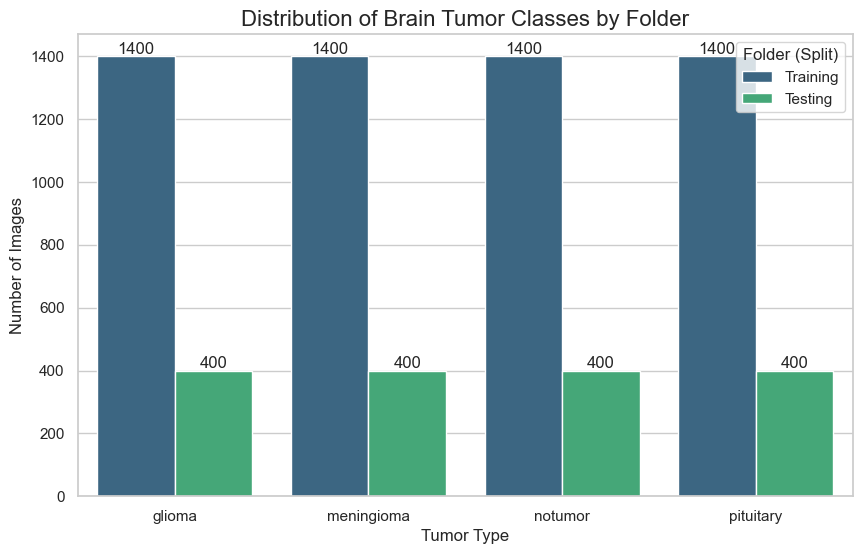

In [16]:
plt.figure(figsize=(10, 6))

# Add hue='split' to separate the counts by folder
ax = sns.countplot(
    data=df, 
    x='label', 
    hue='split', # <--- This is the magic word that groups by folder
    order=df['label'].value_counts().index, 
    palette='viridis'
)

plt.title('Distribution of Brain Tumor Classes by Folder', fontsize=16)
plt.xlabel('Tumor Type', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add counts on top of the bars
for p in ax.patches:
    height = p.get_height()
    
    # Safety check: only annotate if the bar actually has a height > 0
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', 
                    xytext=(0, 5), textcoords='offset points')

# Move the legend so it doesn't block the bars
plt.legend(title='Folder (Split)', loc='upper right')
plt.show()

### 04.Visualizing Sample Images

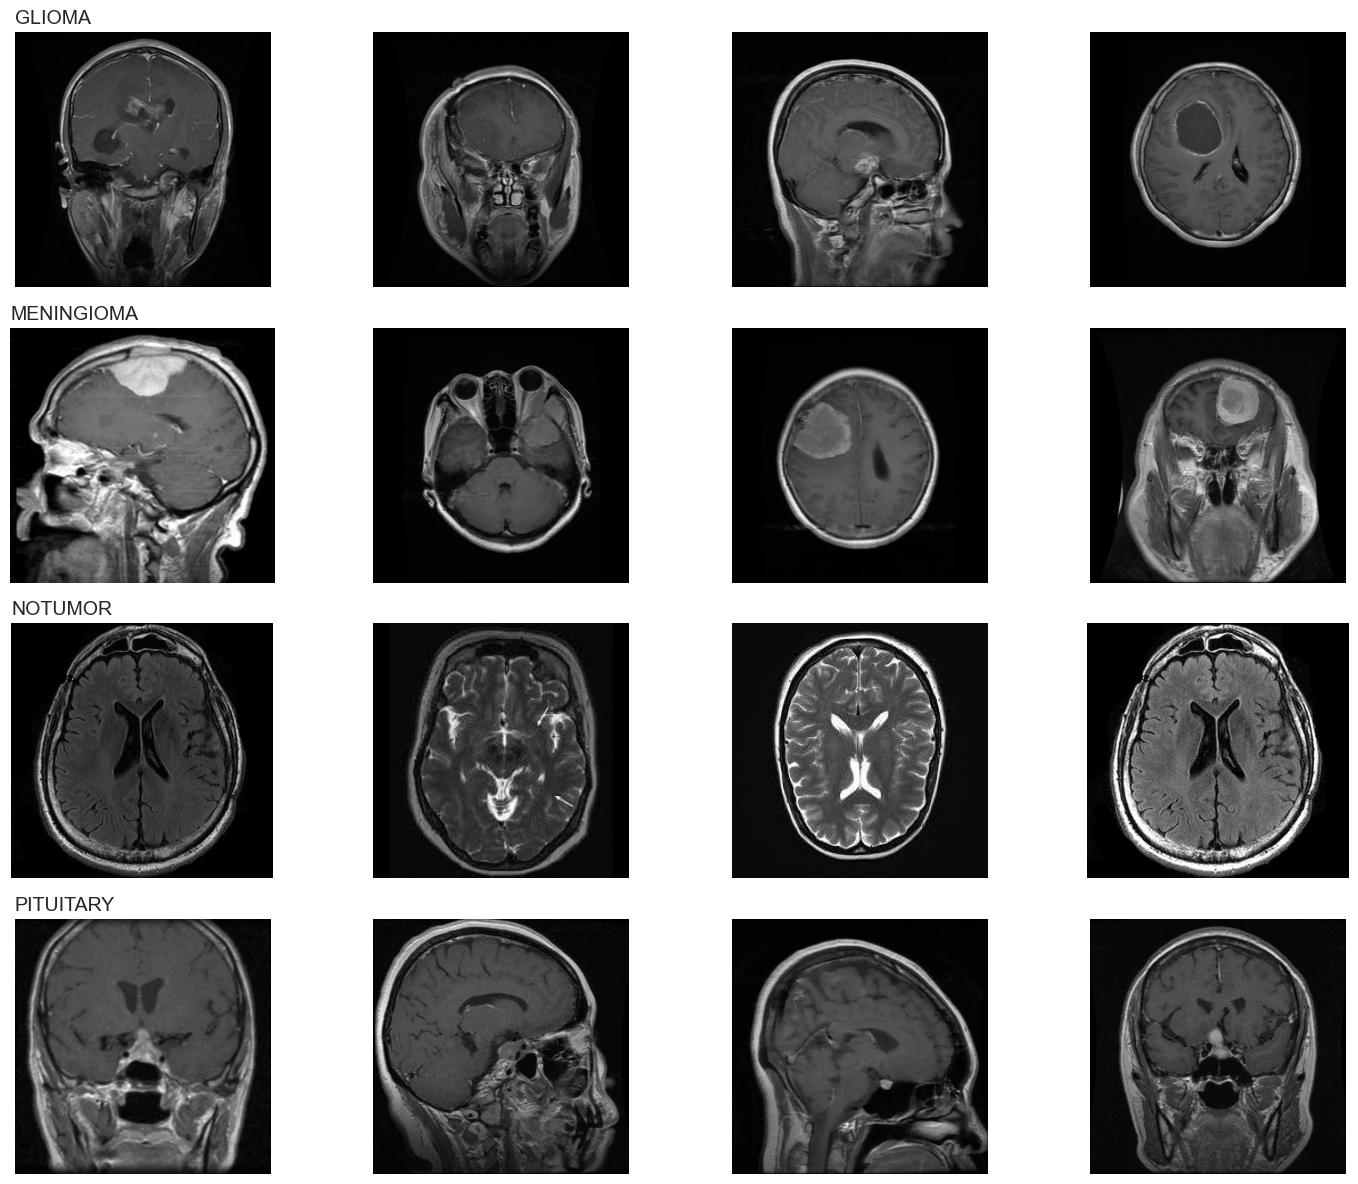

In [17]:
# Function to plot sample images from each class
def plot_sample_images(df, num_samples=4):
    classes = df['label'].unique()
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 3 * len(classes)))
    
    for i, tumor_class in enumerate(classes):
        # Get random samples for the current class
        sample_df = df[df['label'] == tumor_class].sample(num_samples, replace=True)
        
        for j, (_, row) in enumerate(sample_df.iterrows()):
            img_path = row['filepath']
            # Read image in grayscale (typical for MRIs, though some are saved as RGB)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
            
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(tumor_class.upper(), fontsize=14, loc='left')

    plt.tight_layout()
    plt.show()

plot_sample_images(df)

1. Glioma (Top Row)
What it is: Gliomas are one of the most common types of primary brain tumors. They originate in the glial cells, which are the supportive, "sticky" cells that surround and protect neurons in the brain and spinal cord.

Visual Characteristics: * If you look closely at the images in the top row (especially the third image showing a sagittal/side view), the tumor appears as a distinctly bright or abnormal mass deep within the brain tissue itself (the parenchyma).

Gliomas are often infiltrative, meaning their borders can look a bit "fuzzy" or irregular because they grow directly into the surrounding healthy brain matter.

They often cause surrounding swelling (edema), which can distort the normal shape of the brain.

2. Meningioma (Second Row)
What it is: Meningiomas do not actually grow from brain tissue itself. Instead, they arise from the meninges, which are the protective membrane layers that surround the outside of the brain and spinal cord.

Visual Characteristics:

In the second row (particularly the fourth image on the far right), you can see a massive, bright tumor located on the outer surface of the brain.

Because they grow on the outside layers, they tend to have much clearer, well-defined borders compared to gliomas.

Instead of growing into the brain, they usually press inward, squishing and displacing the healthy brain tissue as they get larger.

3. No Tumor (Third Row)
What it is: These are scans of brains that do not contain any neoplastic (tumor) masses.

Visual Characteristics:

These images show normal, symmetrical brain anatomy.

If you look at the axial (top-down) views in this row, the dark, butterfly-like structures in the center are the ventricles (spaces filled with cerebrospinal fluid). Notice how they are largely symmetrical and not being crushed or pushed to one side by a mass.

Note: You might still see some bright spots or variations in these scans (often related to normal aging or minor blood vessel changes), but there is no large, space-occupying lesion.

4. Pituitary Tumor (Bottom Row)
What it is: These tumors develop in the pituitary gland, a tiny, pea-sized organ located at the very base of the brain, just behind the bridge of the nose. This gland regulates the body's hormones.

Visual Characteristics:

Because of where the pituitary gland is located, these tumors always appear in the exact center-bottom of the brain.

Look at the first and second images in the bottom row; the abnormal mass is located centrally, right above the nasal/sinus area.

As they grow, they expand upward from this central pocket (the sella turcica) and can often press on the optic nerves, which is why patients with these tumors frequently experience vision problems.

### 05.Analyzing Image Dimension

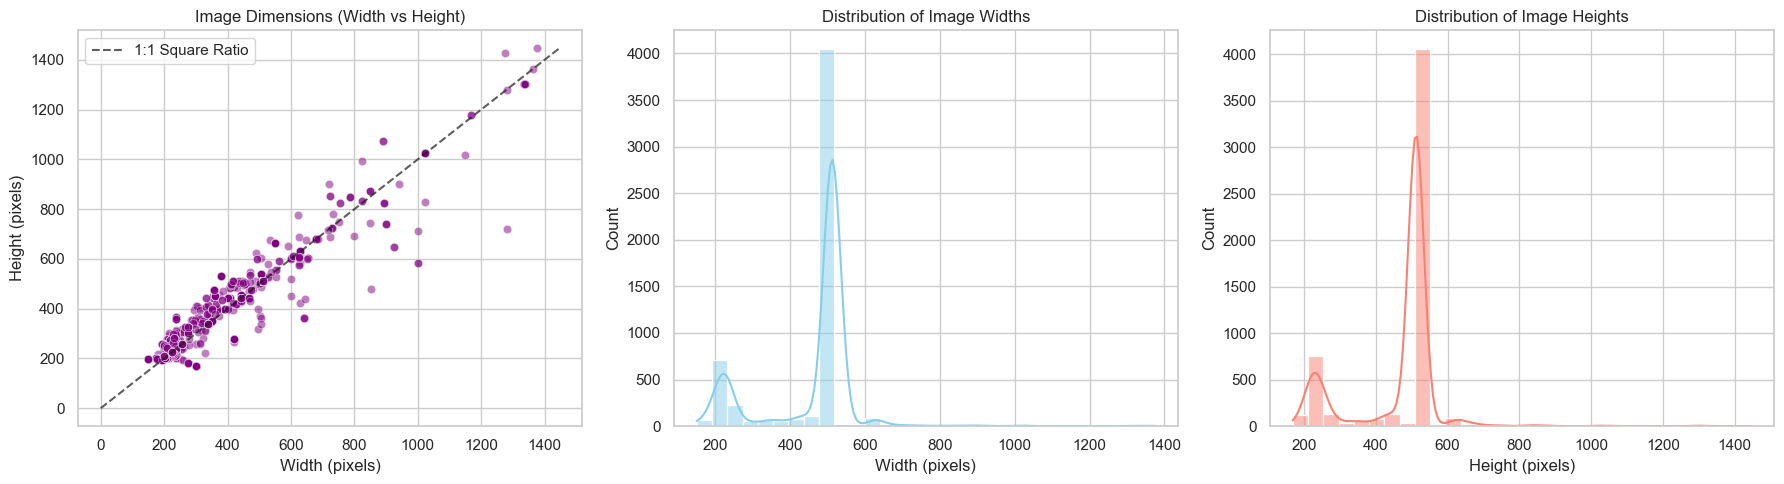

--- Training Image Dimensions Summary ---
Total Images Analyzed: 5600
WIDTH  - Min: 150, Max: 1375, Mean: 459, Median: 512
HEIGHT - Min: 168, Max: 1446, Mean: 462, Median: 512


In [18]:
# 1. Filter for Training data only to prevent data leakage
train_df = df[df['split'] == 'Training']

widths = []
heights = []

# 2. Iterate through training images
# We will process all training images for an exact calculation, 
# but you can add .sample(1000) back to train_df['filepath'] if it takes too long.
for img_path in train_df['filepath']:
    img = cv2.imread(img_path)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

# 3. Create a comprehensive visualization (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Scatter plot of Width vs Height to check aspect ratios
sns.scatterplot(x=widths, y=heights, ax=axes[0], alpha=0.5, color='purple')
axes[0].set_title('Image Dimensions (Width vs Height)')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Height (pixels)')

# Add a dashed line representing perfectly square images (1:1 ratio)
max_dim = max(max(widths), max(heights))
axes[0].plot([0, max_dim], [0, max_dim], 'k--', alpha=0.7, label='1:1 Square Ratio')
axes[0].legend()

# Plot B: Distribution of Widths
sns.histplot(widths, bins=30, ax=axes[1], color='skyblue', kde=True)
axes[1].set_title('Distribution of Image Widths')
axes[1].set_xlabel('Width (pixels)')

# Plot C: Distribution of Heights
sns.histplot(heights, bins=30, ax=axes[2], color='salmon', kde=True)
axes[2].set_title('Distribution of Image Heights')
axes[2].set_xlabel('Height (pixels)')

plt.tight_layout()
plt.show()

# 4. Print a detailed statistical summary for your thesis report
print("--- Training Image Dimensions Summary ---")
print(f"Total Images Analyzed: {len(widths)}")
print(f"WIDTH  - Min: {np.min(widths):.0f}, Max: {np.max(widths):.0f}, Mean: {np.mean(widths):.0f}, Median: {np.median(widths):.0f}")
print(f"HEIGHT - Min: {np.min(heights):.0f}, Max: {np.max(heights):.0f}, Mean: {np.mean(heights):.0f}, Median: {np.median(heights):.0f}")

To upgrade this code for a Master's thesis, we should make three major improvements:

Prevent Data Leakage: Just like our image visualization, we should only analyze the dimensions of the Training split. We don't want our final model architecture choices to be influenced by the test set.

Add a Scatter Plot (Aspect Ratio Check): A scatter plot of Width vs. Height is an industry-standard way to see if your images are mostly square, landscape, or portrait. This is crucial for deciding if you need to pad your images or just stretch them when resizing.

Calculate the Median & Extremes: The average (mean) can be heavily skewed by a few massive or tiny images. Knowing the minimum, maximum, and median dimensions is much more useful when choosing your final neural network input size (like 224x224 or 256x256).